# 01 · SQL Showcase: Customer Behaviour Analytics

**Data:** UCI Online Retail II (UK online gift-ware retailer, Dec 2009 – Dec 2011, CC BY 4.0), loaded into a DuckDB star schema by `python -m src.build_warehouse`.

**How this notebook works:** every query lives in `sql/analytics/qXX_*.sql` and answers **one business question**. This notebook only runs each file, shows the SQL and the result, and prints findings **computed from the data**. No logic is hidden in Python.

| # | Business question |
|---|---|
| Q01 | Who are the top customers and how concentrated is revenue? |
| Q02 | How do revenue, orders and active customers move month by month? |
| Q03 | What does weekly revenue look like and which weeks peak? |
| Q04 | On which days and at what times do customers order? |
| Q05 | How do customers split into RFM segments? |
| Q06 | What share of new customers come back, and how fast? |
| Q07 | How does each customer's spend evolve over time? |
| Q08 | Which products lead each category? |
| Q09 | How well are monthly cohorts retained? |
| Q10 | Which customers have lapsed relative to their own rhythm? |

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.analytics import query_header, run_query, sql_text
from src.config import path
from src.db import connect

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
FIG_DIR = path("reports_dir") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
con = connect(read_only=True)


def show(name: str, n: int = 15) -> pd.DataFrame:
    """Display the business question, the SQL and the first n result rows."""
    h = query_header(name)
    display(Markdown(f"**Question:** {h['question']}  \n**Techniques:** {h['techniques']}"
                     + (f"  \n**Notes:** {h['notes']}" if h['notes'] else "")))
    display(Markdown(f"```sql\n{sql_text(name)}\n```"))
    df = run_query(con, name)
    display(df.head(n))
    print(f"{len(df):,} rows returned")
    return df

## Q01 · Top customers

In [2]:
top = show("q01_top_customers")
print(f"Top 10 customers = {top['cumulative_pct'].iloc[-1]:.1f}% of identified-customer net revenue; "
      f"#1 alone = {top['pct_of_customer_revenue'].iloc[0]:.1f}%.")
print("Countries among the top 10:", top["country"].value_counts().to_dict())

**Question:** Which 10 customers generate the most net revenue, and how concentrated is revenue among them?  
**Techniques:** CTE, INNER JOIN, GROUP BY, FILTER aggregate, RANK(), SUM() OVER () share, running SUM() OVER (ORDER BY ...)  
**Notes:** net revenue = sales minus cancellations. Only identified customers.

```sql
WITH customer_revenue AS (
    SELECT f.customer_id,
           SUM(f.line_amount)                                           AS net_revenue,
           COUNT(DISTINCT f.invoice_no) FILTER (WHERE NOT f.is_cancel)  AS n_orders
    FROM core.fact_line AS f
    WHERE f.customer_id IS NOT NULL
    GROUP BY f.customer_id
),
ranked AS (
    SELECT cr.customer_id,
           d.country,
           cr.n_orders,
           ROUND(cr.net_revenue, 2)                                      AS net_revenue,
           RANK() OVER (ORDER BY cr.net_revenue DESC)                    AS revenue_rank,
           ROUND(100.0 * cr.net_revenue / SUM(cr.net_revenue) OVER (), 2) AS pct_of_customer_revenue,
           ROUND(100.0 * SUM(cr.net_revenue) OVER (
                     ORDER BY cr.net_revenue DESC, cr.customer_id
                     ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                 / SUM(cr.net_revenue) OVER (), 2)                      AS cumulative_pct
    FROM customer_revenue AS cr
    INNER JOIN core.dim_customer AS d
            ON d.customer_id = cr.customer_id
)
SELECT *
FROM ranked
WHERE revenue_rank <= 10
ORDER BY revenue_rank;
```

,customer_id,country,n_orders,net_revenue,revenue_rank,pct_of_customer_revenue,cumulative_pct
0,18102,United Kingdom,145,578408.64,1,3.54,3.54
1,14646,Netherlands,145,523202.74,2,3.20,6.73
2,14156,EIRE,144,297775.01,3,1.82,8.55
3,14911,EIRE,373,258522.43,4,1.58,10.13
4,17450,United Kingdom,51,233643.91,5,1.43,11.56
5,13694,United Kingdom,143,190391.50,6,1.16,12.73
6,17511,United Kingdom,60,168504.44,7,1.03,13.76
7,12415,Australia,24,143107.02,8,0.87,14.63
8,16684,United Kingdom,55,141530.29,9,0.87,15.50
9,15061,United Kingdom,127,124982.13,10,0.76,16.26


10 rows returned
Top 10 customers = 16.3% of identified-customer net revenue; #1 alone = 3.5%.
Countries among the top 10: {'United Kingdom': 6, 'EIRE': 2, 'Netherlands': 1, 'Australia': 1}


## Q02 · Monthly revenue

**Question:** How do sales, cancellations, orders and active customers move month by month, and how fast is revenue growing?  
**Techniques:** DATE_TRUNC monthly aggregation, FILTER aggregates, LAG() for MoM and YoY growth, AVG() OVER (ROWS 2 PRECEDING) moving average, scalar subquery  
**Notes:** Dec-2011 contains data only up to 9 Dec, so it is flagged as a partial month. Includes guest (no customer ID) revenue.

```sql
WITH monthly AS (
    SELECT DATE_TRUNC('month', invoice_date)                          AS month,
           SUM(line_amount) FILTER (WHERE NOT is_cancel)              AS gross_sales,
           -SUM(line_amount) FILTER (WHERE is_cancel)                 AS cancelled_value,
           SUM(line_amount)                                           AS net_revenue,
           COUNT(DISTINCT invoice_no) FILTER (WHERE NOT is_cancel)    AS n_orders,
           COUNT(DISTINCT customer_id) FILTER (WHERE NOT is_cancel)   AS active_customers
    FROM core.fact_line
    GROUP BY 1
)
SELECT CAST(month AS DATE)                                               AS month,
       ROUND(gross_sales, 2)                                             AS gross_sales,
       ROUND(COALESCE(cancelled_value, 0), 2)                            AS cancelled_value,
       ROUND(net_revenue, 2)                                             AS net_revenue,
       n_orders,
       active_customers,
       ROUND(gross_sales / NULLIF(n_orders, 0), 2)                       AS avg_order_value,
       ROUND(100.0 * (net_revenue - LAG(net_revenue) OVER (ORDER BY month))
             / NULLIF(LAG(net_revenue) OVER (ORDER BY month), 0), 1)     AS mom_growth_pct,
       ROUND(100.0 * (net_revenue - LAG(net_revenue, 12) OVER (ORDER BY month))
             / NULLIF(LAG(net_revenue, 12) OVER (ORDER BY month), 0), 1) AS yoy_growth_pct,
       ROUND(AVG(net_revenue) OVER (ORDER BY month
             ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2)               AS net_revenue_3m_avg,
       month = (SELECT MAX(DATE_TRUNC('month', invoice_date)) FROM core.fact_line) AS is_partial_month
FROM monthly
ORDER BY month;
```

,month,gross_sales,cancelled_value,net_revenue,n_orders,active_customers,avg_order_value,mom_growth_pct,yoy_growth_pct,net_revenue_3m_avg,is_partial_month
0,2009-12-01,797738.02,19558.08,778179.94,1666,951,478.83,NaN,NaN,778179.94,False
1,2010-01-01,612271.20,7465.63,604805.57,1049,701,583.67,-22.3,NaN,691492.76,False
2,2010-02-01,537893.54,12575.44,525318.10,1189,771,452.39,-13.1,NaN,636101.20,False
3,2010-03-01,761665.62,9603.85,752061.77,1647,1051,462.46,43.2,NaN,627395.15,False
4,2010-04-01,646233.18,10025.26,636207.92,1435,939,450.34,-15.4,NaN,637862.60,False
5,2010-05-01,643474.28,37192.89,606281.39,1484,965,433.61,-4.7,NaN,664850.36,False
6,2010-06-01,696439.47,26336.86,670102.61,1612,1034,432.03,10.5,NaN,637530.64,False
7,2010-07-01,632983.51,17132.73,615850.78,1507,924,420.03,-8.1,NaN,630744.93,False
8,2010-08-01,674036.87,12397.60,661639.27,1402,910,480.77,7.4,NaN,649197.55,False
9,2010-09-01,869224.44,27686.42,841538.02,1789,1136,485.87,27.2,NaN,706342.69,False


25 rows returned


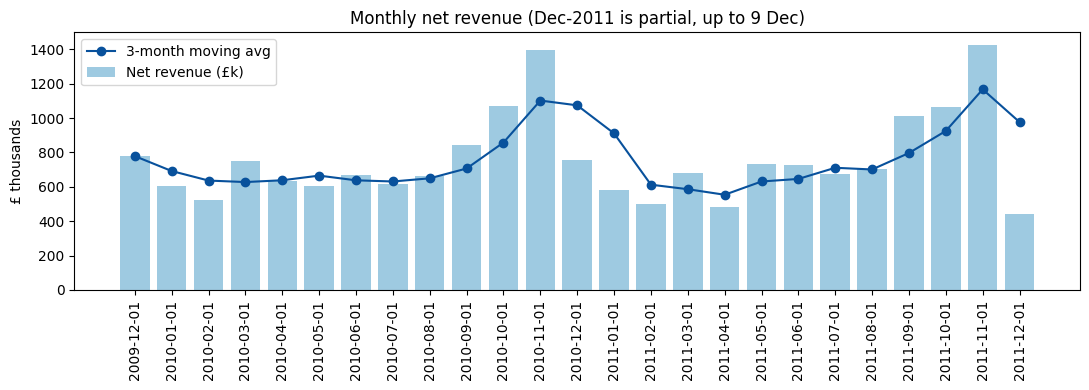

Peak full month: 2011-11-01 00:00:00 with £1,427,121 net revenue and 1,660 active customers.
Cancellations = 3.6% of gross sales over the period.


In [3]:
monthly = show("q02_monthly_revenue", n=25)
full = monthly[~monthly["is_partial_month"]]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly["month"].astype(str), monthly["net_revenue"] / 1e3, color="#9ecae1", label="Net revenue (£k)")
ax.plot(monthly["month"].astype(str), monthly["net_revenue_3m_avg"] / 1e3, color="#08519c", marker="o", label="3-month moving avg")
ax.set_title("Monthly net revenue (Dec-2011 is partial, up to 9 Dec)")
ax.set_ylabel("£ thousands"); ax.tick_params(axis="x", rotation=90); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "q02_monthly_revenue.png", dpi=120); plt.show()

peak = full.loc[full["net_revenue"].idxmax()]
print(f"Peak full month: {peak['month']} with £{peak['net_revenue']:,.0f} net revenue "
      f"and {peak['active_customers']:,} active customers.")
print(f"Cancellations = {100 * monthly['cancelled_value'].sum() / monthly['gross_sales'].sum():.1f}% of gross sales over the period.")

## Q03 · Weekly revenue and best weeks per year

**Question:** What does the weekly revenue curve look like, and which weeks were the strongest in each year?  
**Techniques:** INNER JOIN to dim_date, weekly aggregation (ISO week start), LAG() week-over-week change, DENSE_RANK() OVER (PARTITION BY year)

```sql
WITH weekly AS (
    SELECT d.week_start,
           SUM(f.line_amount)                                           AS net_revenue,
           COUNT(DISTINCT f.invoice_no) FILTER (WHERE NOT f.is_cancel)  AS n_orders
    FROM core.fact_line AS f
    INNER JOIN core.dim_date AS d
            ON d.date_key = f.invoice_date
    GROUP BY d.week_start
)
SELECT week_start,
       year(week_start)                                                  AS year,
       ROUND(net_revenue, 2)                                             AS net_revenue,
       n_orders,
       ROUND(net_revenue - LAG(net_revenue) OVER (ORDER BY week_start), 2) AS wow_change,
       DENSE_RANK() OVER (PARTITION BY year(week_start)
                          ORDER BY net_revenue DESC)                     AS rank_in_year
FROM weekly
ORDER BY week_start;
```

,week_start,year,net_revenue,n_orders,wow_change,rank_in_year
0,2009-11-30,2009,254418.07,548,NaN,1
1,2009-12-07,2009,225086.03,525,-29332.04,3
2,2009-12-14,2009,248869.79,486,23783.76,2
3,2009-12-21,2009,49806.05,107,-199063.74,4
4,2010-01-04,2010,164721.85,200,114915.80,20
5,2010-01-11,2010,153851.81,262,-10870.04,29
6,2010-01-18,2010,143267.27,262,-10584.54,36
7,2010-01-25,2010,142964.64,325,-302.63,37
8,2010-02-01,2010,118850.04,288,-24114.60,48
9,2010-02-08,2010,85442.15,276,-33407.89,50


104 rows returned


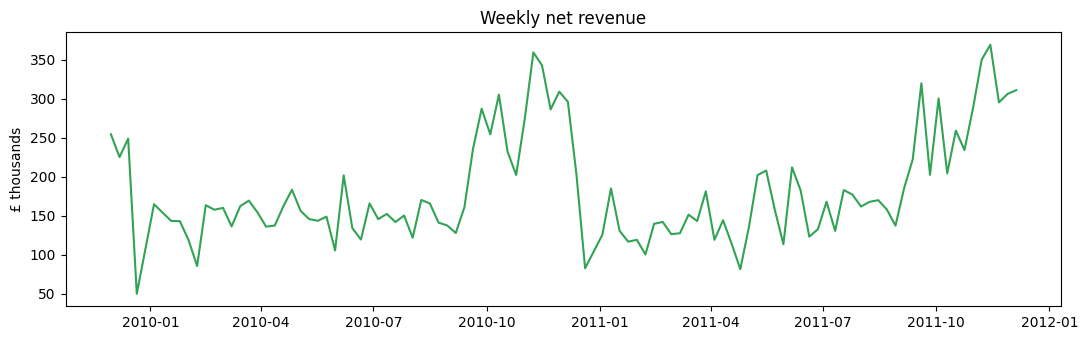

Best week of each year:


,year,week_start,net_revenue,n_orders
0,2009,2009-11-30,254418.07,548
48,2010,2010-11-08,359362.74,657
100,2011,2011-11-14,369126.18,687


In [4]:
weekly = show("q03_weekly_revenue", n=10)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(weekly["week_start"], weekly["net_revenue"] / 1e3, color="#31a354")
ax.set_title("Weekly net revenue"); ax.set_ylabel("£ thousands")
plt.tight_layout(); plt.savefig(FIG_DIR / "q03_weekly_revenue.png", dpi=120); plt.show()

print("Best week of each year:")
display(weekly[weekly["rank_in_year"] == 1][["year", "week_start", "net_revenue", "n_orders"]])

## Q04 · When do customers order?

**Question:** On which weekdays and at which times of day are orders placed? (Useful for timing outreach messages.)  
**Techniques:** INNER JOIN fact_invoice to dim_date, CASE WHEN hour bands, hour() extraction, GROUP BY alias, share via SUM(COUNT(*)) OVER ()  
**Notes:** timestamps are the retailer's system time (UK). Weekdays with no rows simply do not appear.

```sql
WITH orders AS (
    SELECT fi.invoice_no,
           fi.invoice_ts,
           fi.invoice_amount,
           d.iso_dow,
           d.day_name
    FROM core.fact_invoice AS fi
    INNER JOIN core.dim_date AS d
            ON d.date_key = fi.invoice_date
    WHERE NOT fi.is_cancel
)
SELECT iso_dow,
       day_name,
       CASE
           WHEN hour(invoice_ts) < 10 THEN '1_before_10h'
           WHEN hour(invoice_ts) < 13 THEN '2_10h_to_13h'
           WHEN hour(invoice_ts) < 16 THEN '3_13h_to_16h'
           ELSE                            '4_16h_onwards'
       END                                                       AS hour_band,
       COUNT(*)                                                  AS n_orders,
       ROUND(SUM(invoice_amount), 2)                             AS revenue,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)        AS pct_of_orders
FROM orders
GROUP BY iso_dow, day_name, hour_band
ORDER BY iso_dow, hour_band;
```

,iso_dow,day_name,hour_band,n_orders,revenue,pct_of_orders
0,1,Monday,1_before_10h,681,407407.11,1.72
1,1,Monday,2_10h_to_13h,2442,1200541.00,6.18
2,1,Monday,3_13h_to_16h,2475,1174514.57,6.26
3,1,Monday,4_16h_onwards,647,633737.04,1.64
4,2,Tuesday,1_before_10h,842,465482.54,2.13
5,2,Tuesday,2_10h_to_13h,2740,1552952.42,6.93
6,2,Tuesday,3_13h_to_16h,2688,1351726.17,6.80
7,2,Tuesday,4_16h_onwards,877,509772.50,2.22
8,3,Wednesday,1_before_10h,765,384862.81,1.94
9,3,Wednesday,2_10h_to_13h,2877,1441591.08,7.28


27 rows returned


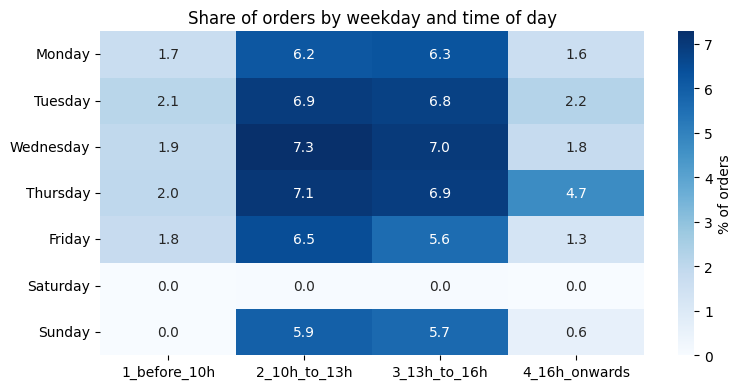

Busiest day: Thursday (20.7% of orders).
Weekdays with no orders at all: none


In [5]:
timing = show("q04_weekday_hour_activity", n=30)

grid = (timing.pivot_table(index=["iso_dow", "day_name"], columns="hour_band",
                           values="pct_of_orders", aggfunc="sum", fill_value=0)
              .reset_index(level=0, drop=True))
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(grid, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of orders"}, ax=ax)
ax.set_title("Share of orders by weekday and time of day"); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIG_DIR / "q04_weekday_hour.png", dpi=120); plt.show()

by_day = timing.groupby("day_name")["pct_of_orders"].sum().sort_values(ascending=False)
missing = sorted(set(range(1, 8)) - set(timing["iso_dow"]))
names = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}
print(f"Busiest day: {by_day.index[0]} ({by_day.iloc[0]:.1f}% of orders).")
print("Weekdays with no orders at all:", [names[d] for d in missing] or "none")

## Q05 · RFM segmentation (rule-based baseline)

**Question:** How do customers split by Recency, Frequency and Monetary value, and how much revenue does each RFM segment hold?  
**Techniques:** CROSS JOIN reference date, date math (date_diff, INTERVAL), HAVING, NTILE(5) quintile scoring, CASE WHEN segment rules, SUM(SUM()) OVER () share  
**Notes:** descriptive, full-history snapshot as of the day after the last invoice. This is the rule-based baseline that the ML segmentation (Step 5) is compared against. Ties broken by customer_id for determinism.

```sql
WITH ref AS (
    SELECT CAST(MAX(invoice_date) + INTERVAL 1 DAY AS DATE) AS ref_date
    FROM core.fact_line
),
base AS (
    SELECT f.customer_id,
           date_diff('day', MAX(f.invoice_date) FILTER (WHERE NOT f.is_cancel), r.ref_date) AS recency_days,
           COUNT(DISTINCT f.invoice_no) FILTER (WHERE NOT f.is_cancel)                      AS frequency,
           SUM(f.line_amount)                                                               AS monetary
    FROM core.fact_line AS f
    CROSS JOIN ref AS r
    WHERE f.customer_id IS NOT NULL
    GROUP BY f.customer_id, r.ref_date
    HAVING COUNT(DISTINCT f.invoice_no) FILTER (WHERE NOT f.is_cancel) > 0
       AND SUM(f.line_amount) > 0
),
scored AS (
    SELECT *,
           NTILE(5) OVER (ORDER BY recency_days DESC, customer_id) AS r_score,  -- 5 = most recent
           NTILE(5) OVER (ORDER BY frequency ASC,  customer_id)    AS f_score,  -- 5 = most frequent
           NTILE(5) OVER (ORDER BY monetary ASC,   customer_id)    AS m_score   -- 5 = highest value
    FROM base
),
segmented AS (
    SELECT *,
           CASE
               WHEN r_score >= 4 AND f_score >= 4 THEN 'Champions'
               WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal'
               WHEN r_score >= 4 AND f_score <= 2 THEN 'Recent low-frequency'
               WHEN r_score <= 2 AND f_score >= 3 THEN 'At risk (previously frequent)'
               WHEN r_score <= 2 AND f_score <= 2 THEN 'Hibernating'
               ELSE                                    'Needs attention'
           END AS rfm_segment
    FROM scored
)
SELECT rfm_segment,
       COUNT(*)                                                        AS n_customers,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)              AS pct_customers,
       ROUND(median(recency_days), 0)                                  AS median_recency_days,
       ROUND(median(frequency), 1)                                     AS median_frequency,
       ROUND(median(monetary), 2)                                      AS median_monetary,
       ROUND(100.0 * SUM(monetary) / SUM(SUM(monetary)) OVER (), 1)    AS pct_revenue
FROM segmented
GROUP BY rfm_segment
ORDER BY pct_revenue DESC;
```

,rfm_segment,n_customers,pct_customers,median_recency_days,median_frequency,median_monetary,pct_revenue
0,Champions,1455,24.9,17.0,10.0,3289.66,70.0
1,Loyal,1217,20.9,72.0,4.0,1176.46,14.8
2,At risk (previously frequent),826,14.2,373.0,4.0,1008.54,8.8
3,Hibernating,1508,25.9,433.0,1.0,268.28,3.7
4,Recent low-frequency,446,7.6,26.0,1.0,363.78,1.5
5,Needs attention,380,6.5,93.0,1.0,356.55,1.2


6 rows returned


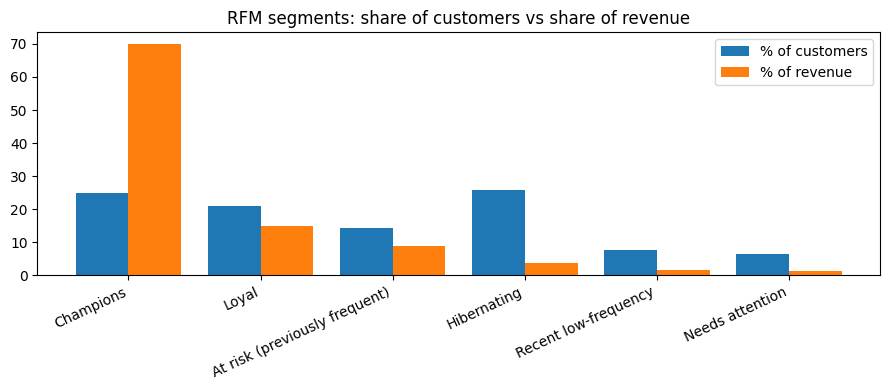

Champions: 24.9% of customers hold 70.0% of revenue.


In [6]:
rfm = show("q05_rfm_segments")

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(rfm))
ax.bar([i - 0.2 for i in x], rfm["pct_customers"], width=0.4, label="% of customers")
ax.bar([i + 0.2 for i in x], rfm["pct_revenue"], width=0.4, label="% of revenue")
ax.set_xticks(list(x)); ax.set_xticklabels(rfm["rfm_segment"], rotation=25, ha="right")
ax.set_title("RFM segments: share of customers vs share of revenue"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "q05_rfm_segments.png", dpi=120); plt.show()

champ = rfm[rfm["rfm_segment"] == "Champions"].iloc[0]
print(f"Champions: {champ['pct_customers']:.1f}% of customers hold {champ['pct_revenue']:.1f}% of revenue.")

## Q06 · Repeat-purchase rate by market and acquisition quarter

In [7]:
repeat = show("q06_repeat_rate", n=20)
summary = repeat.groupby("market").apply(
    lambda g: pd.Series({"new_customers": g["new_customers"].sum(),
                         "weighted_repeat_within_90d_pct": (g["repeat_within_90d_pct"] * g["new_customers"]).sum() / g["new_customers"].sum()}),
    include_groups=False)
display(summary.round(1))

**Question:** What share of new customers place a second order (at all, and within 90 days), by market and acquisition quarter?  
**Techniques:** ROW_NUMBER() to sequence orders, LEFT JOIN (NULL = never repeated), CASE WHEN market, date_diff, FILTER, HAVING  
**Notes:** Dec-2009 is excluded: its "first" orders include customers who existed before the data starts (left-censoring). Later quarters had less time to repeat (right-censoring), so compare repeat_within_90d_pct, not repeat_rate_pct, and treat the last quarter with caution.

```sql
WITH orders AS (
    SELECT customer_id,
           invoice_no,
           invoice_date,
           ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY invoice_ts, invoice_no) AS order_seq
    FROM core.fact_invoice
    WHERE customer_id IS NOT NULL
      AND NOT is_cancel
),
first_order  AS (SELECT customer_id, invoice_date AS first_date  FROM orders WHERE order_seq = 1),
second_order AS (SELECT customer_id, invoice_date AS second_date FROM orders WHERE order_seq = 2),
customers AS (
    SELECT fo.customer_id,
           CASE WHEN d.country = 'United Kingdom' THEN 'UK' ELSE 'International' END      AS market,
           CAST(year(fo.first_date) AS VARCHAR) || '-Q' || CAST(quarter(fo.first_date) AS VARCHAR) AS first_quarter,
           so.second_date,
           date_diff('day', fo.first_date, so.second_date)                                 AS days_to_second
    FROM first_order AS fo
    INNER JOIN core.dim_customer AS d
            ON d.customer_id = fo.customer_id
    LEFT JOIN second_order AS so
           ON so.customer_id = fo.customer_id
)
SELECT market,
       first_quarter,
       COUNT(*)                                                                   AS new_customers,
       COUNT(second_date)                                                         AS repeated,
       ROUND(100.0 * COUNT(second_date) / COUNT(*), 1)                            AS repeat_rate_pct,
       ROUND(100.0 * COUNT(*) FILTER (WHERE days_to_second <= 90) / COUNT(*), 1)  AS repeat_within_90d_pct,
       median(days_to_second)                                                     AS median_days_to_second
FROM customers
WHERE first_quarter <> '2009-Q4'
GROUP BY market, first_quarter
HAVING COUNT(*) >= 30
ORDER BY market, first_quarter;
```

,market,first_quarter,new_customers,repeated,repeat_rate_pct,repeat_within_90d_pct,median_days_to_second
0,International,2010-Q1,89,78,87.6,48.3,77.0
1,International,2010-Q2,71,56,78.9,33.8,121.0
2,International,2010-Q3,59,43,72.9,52.5,68.0
3,International,2010-Q4,70,46,65.7,40.0,61.0
4,International,2011-Q1,40,24,60.0,37.5,74.0
5,International,2011-Q2,41,31,75.6,58.5,51.0
6,International,2011-Q3,51,29,56.9,43.1,45.0
7,International,2011-Q4,48,13,27.1,27.1,31.0
8,UK,2010-Q1,1095,932,85.1,49.6,71.0
9,UK,2010-Q2,745,576,77.3,38.9,89.5


16 rows returned


,new_customers,weighted_repeat_within_90d_pct
market,,
International,469.0,42.6
UK,4432.0,42.9


## Q07 · Spend trend of one customer

**Question:** For each customer, how does monthly spend evolve: gap since the previous active month, change vs that month, the next active month, running lifetime spend and a rolling average?  
**Techniques:** monthly aggregation, LAG() and LEAD() over a named WINDOW, date_diff in months, running SUM() OVER (ROWS UNBOUNDED PRECEDING), rolling AVG() OVER (ROWS 2 PRECEDING), PARTITION BY customer  
**Notes:** one row per customer-month with activity. The notebook plots one customer from this table.

```sql
WITH customer_month AS (
    SELECT customer_id,
           CAST(DATE_TRUNC('month', invoice_date) AS DATE)             AS month,
           SUM(line_amount)                                            AS net_spend,
           COUNT(DISTINCT invoice_no) FILTER (WHERE NOT is_cancel)     AS n_orders
    FROM core.fact_line
    WHERE customer_id IS NOT NULL
    GROUP BY 1, 2
)
SELECT customer_id,
       month,
       ROUND(net_spend, 2)                                       AS net_spend,
       n_orders,
       LAG(month) OVER w                                         AS prev_active_month,
       date_diff('month', LAG(month) OVER w, month)              AS months_since_prev,
       ROUND(net_spend - LAG(net_spend) OVER w, 2)               AS change_vs_prev,
       LEAD(month) OVER w                                        AS next_active_month,
       ROUND(SUM(net_spend) OVER (PARTITION BY customer_id ORDER BY month
             ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 2) AS cumulative_spend,
       ROUND(AVG(net_spend) OVER (PARTITION BY customer_id ORDER BY month
             ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2)       AS rolling_3_active_month_avg
FROM customer_month
WINDOW w AS (PARTITION BY customer_id ORDER BY month)
ORDER BY customer_id, month;
```

,customer_id,month,net_spend,n_orders,prev_active_month,months_since_prev,change_vs_prev,next_active_month,cumulative_spend,rolling_3_active_month_avg
0,12346,2010-03-01,27.05,1,NaT,NaN,NaN,2010-06-01,27.05,27.05
1,12346,2010-06-01,142.31,1,2010-03-01,3.0,115.26,2011-01-01,169.36,84.68
2,12346,2011-01-01,0.00,1,2010-06-01,7.0,-142.31,NaT,169.36,56.45
3,12347,2010-10-01,611.53,1,NaT,NaN,NaN,2010-12-01,611.53,611.53
4,12347,2010-12-01,711.79,1,2010-10-01,2.0,100.26,2011-01-01,1323.32,661.66
5,12347,2011-01-01,475.39,1,2010-12-01,1.0,-236.40,2011-04-01,1798.71,599.57
6,12347,2011-04-01,636.25,1,2011-01-01,3.0,160.86,2011-06-01,2434.96,607.81
7,12347,2011-06-01,382.52,1,2011-04-01,2.0,-253.73,2011-08-01,2817.48,498.05
8,12347,2011-08-01,584.91,1,2011-06-01,2.0,202.39,2011-10-01,3402.39,534.56
9,12347,2011-10-01,1294.32,1,2011-08-01,2.0,709.41,2011-12-01,4696.71,753.92


26,796 rows returned


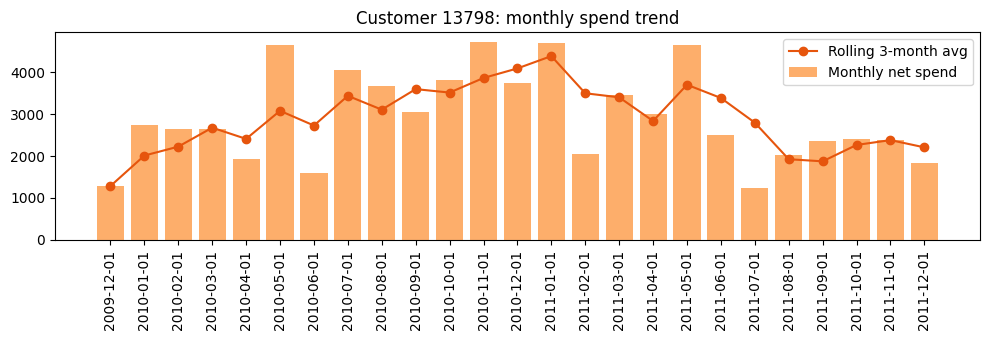

Customer 13798 was active in 25 months; lifetime net spend £73,178.


In [8]:
trend = show("q07_customer_spend_trend", n=12)

most_active = trend["customer_id"].value_counts().idxmax()
one = trend[trend["customer_id"] == most_active]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(one["month"].astype(str), one["net_spend"], color="#fdae6b", label="Monthly net spend")
ax.plot(one["month"].astype(str), one["rolling_3_active_month_avg"], color="#e6550d", marker="o", label="Rolling 3-month avg")
ax.set_title(f"Customer {most_active}: monthly spend trend"); ax.tick_params(axis="x", rotation=90); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "q07_customer_trend.png", dpi=120); plt.show()
print(f"Customer {most_active} was active in {len(one)} months; lifetime net spend £{one['cumulative_spend'].iloc[-1]:,.0f}.")

## Q08 · Top 3 products within each category

In [9]:
products = show("q08_rank_within_category", n=30)

**Question:** Which 3 products lead each product group by revenue, and how do their revenue, reach and unit ranks compare?  
**Techniques:** INNER JOIN fact_line to dim_product, ROW_NUMBER() vs RANK() vs DENSE_RANK() OVER (PARTITION BY product_group), share within group via SUM() OVER (PARTITION BY ...)  
**Notes:** ROW_NUMBER never ties (unique 1,2,3), RANK skips after ties (1,1,3), DENSE_RANK does not skip (1,1,2). product_group is the heuristic keyword taxonomy; 'other' and 'unknown' are excluded here.

```sql
WITH product_sales AS (
    SELECT p.product_group,
           p.stock_code,
           p.description,
           SUM(f.line_amount)            AS net_revenue,
           SUM(f.quantity)               AS net_units,
           COUNT(DISTINCT f.customer_id) AS n_customers
    FROM core.fact_line AS f
    INNER JOIN core.dim_product AS p
            ON p.stock_code = f.stock_code
    GROUP BY p.product_group, p.stock_code, p.description
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY product_group ORDER BY net_revenue DESC, stock_code) AS revenue_rank,
           RANK()       OVER (PARTITION BY product_group ORDER BY n_customers DESC)             AS reach_rank,
           DENSE_RANK() OVER (PARTITION BY product_group ORDER BY net_units DESC)               AS units_dense_rank,
           ROUND(100.0 * net_revenue / SUM(net_revenue) OVER (PARTITION BY product_group), 2)   AS pct_of_group_revenue
    FROM product_sales
)
SELECT product_group,
       revenue_rank,
       reach_rank,
       units_dense_rank,
       stock_code,
       description,
       ROUND(net_revenue, 2) AS net_revenue,
       net_units,
       n_customers,
       pct_of_group_revenue
FROM ranked
WHERE revenue_rank <= 3
  AND product_group NOT IN ('other', 'unknown')
ORDER BY product_group, revenue_rank;
```

,product_group,revenue_rank,reach_rank,units_dense_rank,stock_code,description,net_revenue,net_units,n_customers,pct_of_group_revenue
0,bags_storage,1,1,1,85099B,JUMBO BAG RED RETROSPOT,180512.16,95963.0,978,6.45
1,bags_storage,2,10,3,22386,JUMBO BAG PINK POLKADOT,75457.64,38955.0,601,2.69
2,bags_storage,3,2,2,20725,LUNCH BAG RED RETROSPOT,69722.54,39386.0,845,2.49
3,candles_lighting,1,1,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,251781.63,91082.0,1494,15.90
4,candles_lighting,2,19,14,79321,CHILLI LIGHTS,79905.13,15696.0,306,5.05
5,candles_lighting,3,21,8,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95,22028.0,300,4.48
6,garden_outdoor,1,1,1,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,79571.0,1012,20.62
7,garden_outdoor,2,6,3,15056N,EDWARDIAN PARASOL NATURAL,59305.30,11304.0,348,9.51
8,garden_outdoor,3,7,5,15056BL,EDWARDIAN PARASOL BLACK,47652.42,9407.0,322,7.64
9,home_decor,1,1,1,47566,PARTY BUNTING,147079.73,27915.0,894,3.94


27 rows returned


## Q09 · Monthly cohort retention

**Question:** Of the customers who first bought in a given month, what share buy again 1, 2, 3 ... months later?  
**Techniques:** DISTINCT customer-month activity, MIN() cohort assignment, INNER JOIN, date_diff in months, FIRST_VALUE() OVER (PARTITION BY cohort) as cohort size  
**Notes:** cohorts start Jan-2010. The Dec-2009 "cohort" would include customers who existed before the data (left-censoring).

```sql
WITH purchases AS (
    SELECT DISTINCT customer_id,
           CAST(DATE_TRUNC('month', invoice_date) AS DATE) AS activity_month
    FROM core.fact_line
    WHERE customer_id IS NOT NULL
      AND NOT is_cancel
),
cohorts AS (
    SELECT customer_id, MIN(activity_month) AS cohort_month
    FROM purchases
    GROUP BY customer_id
),
activity AS (
    SELECT c.cohort_month,
           date_diff('month', c.cohort_month, p.activity_month) AS months_since_first,
           COUNT(DISTINCT p.customer_id)                        AS active_customers
    FROM purchases AS p
    INNER JOIN cohorts AS c
            ON c.customer_id = p.customer_id
    GROUP BY 1, 2
)
SELECT cohort_month,
       months_since_first,
       active_customers,
       FIRST_VALUE(active_customers) OVER (PARTITION BY cohort_month ORDER BY months_since_first) AS cohort_size,
       ROUND(100.0 * active_customers
             / FIRST_VALUE(active_customers) OVER (PARTITION BY cohort_month ORDER BY months_since_first), 1) AS retention_pct
FROM activity
WHERE cohort_month >= DATE '2010-01-01'
ORDER BY cohort_month, months_since_first;
```

,cohort_month,months_since_first,active_customers,cohort_size,retention_pct
0,2010-01-01,0,368,368,100.0
1,2010-01-01,1,79,368,21.5
2,2010-01-01,2,118,368,32.1
3,2010-01-01,3,116,368,31.5
4,2010-01-01,4,100,368,27.2
5,2010-01-01,5,114,368,31.0
6,2010-01-01,6,99,368,26.9
7,2010-01-01,7,86,368,23.4
8,2010-01-01,8,105,368,28.5
9,2010-01-01,9,120,368,32.6


300 rows returned


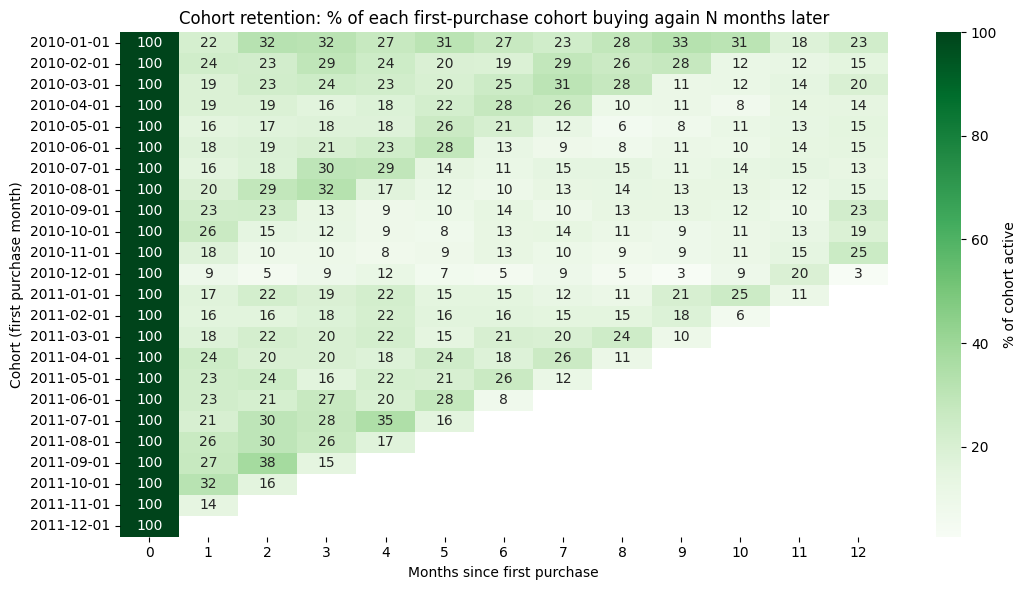

Month-1 retention across cohorts: median 19.6% (range 9.2% to 31.7%).


In [10]:
cohort = show("q09_cohort_retention", n=15)

matrix = (cohort[cohort["months_since_first"] <= 12]
          .pivot(index="cohort_month", columns="months_since_first", values="retention_pct"))
matrix.index = matrix.index.astype(str)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Greens", cbar_kws={"label": "% of cohort active"}, ax=ax)
ax.set_title("Cohort retention: % of each first-purchase cohort buying again N months later")
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort (first purchase month)")
plt.tight_layout(); plt.savefig(FIG_DIR / "q09_cohort_retention.png", dpi=120); plt.show()

m1 = cohort[cohort["months_since_first"] == 1]["retention_pct"]
print(f"Month-1 retention across cohorts: median {m1.median():.1f}% (range {m1.min():.1f}% to {m1.max():.1f}%).")

## Q10 · Lapsed and at-risk customers

In [11]:
lapsed = show("q10_lapsed_customers", n=15)

status = (lapsed.groupby("status")
                .agg(customers=("customer_id", "count"), lifetime_revenue=("lifetime_net_revenue", "sum"))
                .assign(pct_customers=lambda d: (100 * d["customers"] / d["customers"].sum()).round(1),
                        pct_revenue=lambda d: (100 * d["lifetime_revenue"] / d["lifetime_revenue"].sum()).round(1)))
display(status)
risk = status.loc[status.index.isin(["lapsed", "at_risk"])]
print(f"Lapsed + at-risk: {risk['customers'].sum():,} customers who generated {risk['pct_revenue'].sum():.1f}% "
      f"of lifetime revenue. That's the re-engagement target list.")

**Question:** As of the last data date, which customers have gone quiet relative to their OWN usual buying rhythm, and how valuable are they?  
**Techniques:** LAG() for inter-order gaps, median(), CROSS JOIN reference date, INNER + LEFT JOIN, CASE WHEN status rules, GREATEST(), NULLIF  
**Notes:** descriptive rule, not the ML label. 'lapsed'  = days since last order > max(3 x own median gap, 90) 'at_risk' = days since last order > max(1.5 x own median gap, 45) Customers with fewer than 3 orders have no reliable rhythm -> 'insufficient_history'. Business use: the lapsed/at-risk list ranked by value is a re-engagement target list.

```sql
WITH ref AS (
    SELECT MAX(invoice_date) AS ref_date FROM core.fact_line
),
orders AS (
    SELECT customer_id,
           invoice_date,
           date_diff('day',
                     LAG(invoice_date) OVER (PARTITION BY customer_id ORDER BY invoice_ts, invoice_no),
                     invoice_date) AS gap_days
    FROM core.fact_invoice
    WHERE customer_id IS NOT NULL
      AND NOT is_cancel
),
rhythm AS (
    SELECT customer_id,
           COUNT(*)          AS n_orders,
           MAX(invoice_date) AS last_order_date,
           median(gap_days)  AS median_gap_days
    FROM orders
    GROUP BY customer_id
),
lifetime AS (
    SELECT customer_id, SUM(line_amount) AS lifetime_net_revenue
    FROM core.fact_line
    WHERE customer_id IS NOT NULL
    GROUP BY customer_id
),
classified AS (
    SELECT r.customer_id,
           d.country,
           r.n_orders,
           r.last_order_date,
           date_diff('day', r.last_order_date, ref.ref_date)                    AS days_since_last,
           r.median_gap_days,
           ROUND(date_diff('day', r.last_order_date, ref.ref_date)
                 / NULLIF(r.median_gap_days, 0), 1)                            AS overdue_ratio,
           ROUND(l.lifetime_net_revenue, 2)                                     AS lifetime_net_revenue,
           CASE
               WHEN r.n_orders < 3 THEN 'insufficient_history'
               WHEN date_diff('day', r.last_order_date, ref.ref_date) > GREATEST(3.0 * r.median_gap_days, 90) THEN 'lapsed'
               WHEN date_diff('day', r.last_order_date, ref.ref_date) > GREATEST(1.5 * r.median_gap_days, 45) THEN 'at_risk'
               ELSE 'active'
           END                                                                  AS status
    FROM rhythm AS r
    CROSS JOIN ref
    INNER JOIN core.dim_customer AS d
            ON d.customer_id = r.customer_id
    LEFT JOIN lifetime AS l
           ON l.customer_id = r.customer_id
)
SELECT *
FROM classified
ORDER BY CASE status WHEN 'lapsed' THEN 1 WHEN 'at_risk' THEN 2 WHEN 'active' THEN 3 ELSE 4 END,
         lifetime_net_revenue DESC;
```

,customer_id,country,n_orders,last_order_date,days_since_last,median_gap_days,overdue_ratio,lifetime_net_revenue,status
0,16754,United Kingdom,29,2010-12-02,372,6.0,62.0,54692.82,lapsed
1,13093,United Kingdom,55,2011-03-09,275,9.5,28.9,53283.30,lapsed
2,17850,United Kingdom,155,2010-12-02,372,0.0,NaN,50407.77,lapsed
3,15098,United Kingdom,3,2011-06-10,182,0.0,NaN,39619.50,lapsed
4,13902,Denmark,5,2010-03-17,632,26.5,23.8,30375.26,lapsed
5,13802,United Kingdom,19,2011-07-24,138,20.5,6.7,25491.56,lapsed
6,12482,Sweden,27,2010-05-12,576,0.0,NaN,21941.72,lapsed
7,15749,United Kingdom,3,2011-04-18,235,48.5,4.8,21535.90,lapsed
8,13027,United Kingdom,19,2011-08-18,113,27.5,4.1,17143.20,lapsed
9,15808,United Kingdom,21,2011-02-06,306,21.0,14.6,17038.95,lapsed


5,852 rows returned


,customers,lifetime_revenue,pct_customers,pct_revenue
status,,,,
active,2241,12562268.64,38.3,76.8
at_risk,402,1043786.33,6.9,6.4
insufficient_history,2563,1167393.61,43.8,7.1
lapsed,646,1586572.09,11.0,9.7


Lapsed + at-risk: 1,048 customers who generated 16.1% of lifetime revenue. That's the re-engagement target list.


## SQL techniques covered

| Technique | Queries |
|---|---|
| SELECT / WHERE / GROUP BY | all |
| HAVING | Q05, Q06 |
| INNER JOIN | Q01, Q03, Q04, Q06, Q08, Q09, Q10 |
| LEFT JOIN | Q06 (customers with no 2nd order → NULL), Q10 |
| CROSS JOIN | Q05, Q10 (reference date) |
| CASE WHEN | Q04, Q05, Q06, Q10 |
| Date math (`DATE_TRUNC`, `date_diff`, `INTERVAL`) | Q02, Q05, Q06, Q07, Q09, Q10 |
| Monthly / weekly aggregation | Q02, Q07, Q09 / Q03 |
| CTEs | all |
| ROW_NUMBER / RANK / DENSE_RANK / NTILE | Q06, Q08 / Q01, Q08 / Q03, Q08 / Q05 |
| LAG / LEAD | Q02, Q03, Q07, Q10 / Q07 |
| SUM / AVG / FIRST_VALUE OVER (PARTITION BY …) | Q01, Q07, Q08 / Q02, Q07 / Q09 |
| FILTER aggregates, scalar subquery, named WINDOW | Q01, Q02 … / Q02 / Q07 |

The ML feature table (point-in-time `customer_features(cutoff)` macro) is built in the next step and shown in notebook 02.

In [12]:
con.close()